In [3]:
import pandas as pd

In [5]:
# Load the dataset (adjust path as necessary)
df = pd.read_csv("Self source Project(1).csv")

In [7]:
# We reate  new column named 'English' based on 'EnglishLearners' in 'StudentGroup'
df['English'] = df.apply(
    lambda row: row['TotalStudents'] if row['StudentGroup'] == 'English Language Learners' else 0,
    axis=1
)

# Display the updated DataFrame to verify
print(df[['StudentGroup', 'TotalStudents', 'English']].head())

                      StudentGroup  TotalStudents   English
0                     All Students      1148732.0       0.0
1        English Language Learners       169967.0  169967.0
2    Non-English Language Learners       978765.0       0.0
3  American Indian/ Alaskan Native        13780.0       0.0
4                            Asian       101868.0       0.0


In [9]:
import numpy as np

# We Replace 0 values in the 'English' column with random numbers
df['English'] = df['English'].apply(
    lambda x: np.random.randint(1, 1000) if x == 0 else x
)

# Display the updated DataFrame
print(df[['StudentGroup', 'TotalStudents', 'English']].head())

                      StudentGroup  TotalStudents   English
0                     All Students      1148732.0     865.0
1        English Language Learners       169967.0  169967.0
2    Non-English Language Learners       978765.0     676.0
3  American Indian/ Alaskan Native        13780.0     679.0
4                            Asian       101868.0     374.0


In [11]:
# Create a new column 'Ethnicity' based on 'StudentGroupType'
df['Ethnicity'] = df.apply(
    lambda row: row['StudentGroup'] if row['StudentGroupType'] == 'FederalRaceEthnicity' else None,
    axis=1
)

# Display the updated DataFrame to verify
print(df[['StudentGroupType', 'StudentGroup', 'Ethnicity']].head())


       StudentGroupType                     StudentGroup  \
0           AllStudents                     All Students   
1        EnglishLearner        English Language Learners   
2        EnglishLearner    Non-English Language Learners   
3  FederalRaceEthnicity  American Indian/ Alaskan Native   
4  FederalRaceEthnicity                            Asian   

                         Ethnicity  
0                             None  
1                             None  
2                             None  
3  American Indian/ Alaskan Native  
4                            Asian  


In [13]:
# Create a mapping dictionary for ethnicity categories
ethnicity_mapping = {
    'All Students': 1,
    'English Language Learners': 2,
    'Non-English Language Learners': 3,
    'American Indian/ Alaskan Native': 4,
    'Asian': 5,
    'Black/ African American': 6,
    'White': 7,
    'Hispanic/ Latino of any race(s)': 8
}

# Map the Ethnicity column to numerical values and assign 9 to the one not in the list
df['Ethnicity_R'] = df['Ethnicity'].map(ethnicity_mapping).fillna(9).astype(int)

# Display the updated DataFrame to verify
print(df[['Ethnicity', 'Ethnicity_R']].head(10))

                                 Ethnicity  Ethnicity_R
0                                     None            9
1                                     None            9
2                                     None            9
3          American Indian/ Alaskan Native            4
4                                    Asian            5
5                  Black/ African American            6
6          Hispanic/ Latino of any race(s)            8
7  Native Hawaiian/ Other Pacific Islander            9
8                        Two or More Races            9
9                                    White            7


In [15]:
import pandas as pd

# Replace 'None' and NaN values with 'White' in the 'Ethnicity' column
df['Ethnicity'] = df['Ethnicity'].replace(['None', None, 'none'], 'White')

# Fill any NaN values that might still exist
df['Ethnicity'] = df['Ethnicity'].fillna('White')

# Display the updated DataFrame
print(df[['Ethnicity', 'Ethnicity_R']].head(10))


                                 Ethnicity  Ethnicity_R
0                                    White            9
1                                    White            9
2                                    White            9
3          American Indian/ Alaskan Native            4
4                                    Asian            5
5                  Black/ African American            6
6          Hispanic/ Latino of any race(s)            8
7  Native Hawaiian/ Other Pacific Islander            9
8                        Two or More Races            9
9                                    White            7


## Data Cleaning

In [17]:
# Replace 'N<10' with '5%' in the 'HighlyCapableRate' column
df['HighlyCapableRate'] = df['HighlyCapableRate'].replace('N<10', '5%')

# Display the updated DataFrame to verify the changes
print(df['HighlyCapableRate'].head())


0     7.28%
1     1.14%
2     8.34%
3     2.48%
4    17.98%
Name: HighlyCapableRate, dtype: object


In [162]:
# Define a function to clean and convert the values
def clean_highly_capable_rate(value):
    try:
        if isinstance(value, str):  # Ensure the value is a string
            if value == 'N<10':     # Handle 'N<10' specifically
                return 5.0
            elif '<' in value:      # Handle cases like '<15.8'
                return float(value.lstrip('<').strip())
            elif '%' in value:      # Handle percentages
                return float(value.rstrip('%'))
        # If it's already a number, return as float
        return float(value)
    except ValueError:
        # If conversion fails, return NaN
        return float('nan')

# Apply the function to the HighlyCapableRate column
df['HighlyCapableRate'] = df['HighlyCapableRate'].apply(clean_highly_capable_rate)

# Verify the result
print(df['HighlyCapableRate'].head())

20    1.0
21    1.0
22    0.0
23    0.0
24    0.0
Name: HighlyCapableRate, dtype: float64


In [21]:
# Replace 'N<10' with '5%' in the 'HighlyCapableRate' column
df['NonHighlyCapableRate'] = df['NonHighlyCapableRate'].replace('N<10', '5%')

# Display the updated DataFrame to verify the changes
print(df['NonHighlyCapableRate'].head())

0    92.72%
1    98.86%
2    91.66%
3    97.52%
4    82.02%
Name: NonHighlyCapableRate, dtype: object


In [23]:
# Define a function to clean and convert the values
def clean_highly_capable_rate(value):
    try:
        if isinstance(value, str):  # Ensure the value is a string
            if value == 'N<10':     # Handle 'N<10' specifically
                return 5.0
            elif '<' in value:      # Handle cases like '<15.8'
                return float(value.lstrip('<').strip())
            elif '%' in value:      # Handle percentages
                return float(value.rstrip('%'))
        # If it's already a number, return as float
        return float(value)
    except ValueError:
        # If conversion fails, return NaN
        return float('nan')

# Apply the function to the HighlyCapableRate column
df['NonHighlyCapableRate'] = df['NonHighlyCapableRate'].apply(clean_highly_capable_rate)

# Verify the result
print(df['NonHighlyCapableRate'].head())

0    92.72
1    98.86
2    91.66
3    97.52
4    82.02
Name: NonHighlyCapableRate, dtype: float64


In [25]:
# Ensure the column is converted to string
df['HighlyCapableRate'] = df['HighlyCapableRate'].astype(str)

# Remove '%' and convert to float
df['HighlyCapableRate'] = df['HighlyCapableRate'].str.rstrip('%').replace('N<10', '5').replace('<15.8', '15.8').astype(float)

# Define the function to categorize performance
def categorize_performance(rate):
    if rate >= 15:
        return 'High'
    elif 5 <= rate < 15:
        return 'Medium'
    else:
        return 'Low'

# Apply the function to create a new column
df['StudentPerformance'] = df['HighlyCapableRate'].apply(categorize_performance)

# Display the updated DataFrame
print(df[['HighlyCapableRate', 'StudentPerformance']].head())

   HighlyCapableRate StudentPerformance
0               7.28             Medium
1               1.14                Low
2               8.34             Medium
3               2.48                Low
4              17.98               High


In [27]:
def determine_ses(row):
    if any(keyword in row['StudentGroup'] for keyword in ["Low-Income", "Section 504", "Homeless", "Non-Highly Mobile", "Students with Disabilities"]):
        return "Low SES"
    elif any(keyword in row['StudentGroup'] for keyword in ["High-Income", "Non-Low Income", "Income", "Highly Mobile", "Non-English Language Learners"]):
        return "High SES"
    else:
        return "Medium SES"

# Apply the function to create the SocioEconomicStatus column
df['SocioEconomicStatus'] = df.apply(determine_ses, axis=1)

# Save the updated DataFrame to a new CSV file
df.to_csv("updated_with_ses.csv", index=False)

# Display the updated DataFrame
print(df[['StudentGroup', 'SocioEconomicStatus']].head())

                      StudentGroup SocioEconomicStatus
0                     All Students          Medium SES
1        English Language Learners          Medium SES
2    Non-English Language Learners            High SES
3  American Indian/ Alaskan Native          Medium SES
4                            Asian          Medium SES


In [29]:
# identifying missing values
missing_count = df.isnull().sum()

# printing the missing values to take note
print("Missing Values")
print(missing_count)

Missing Values
SchoolYear                          0
OrgLevel                            0
OrganizationID                      0
SchoolName                          0
DistrictOrganizationID             20
DistrictName                        0
StudentGroupType                    0
StudentGroup                        0
DisclosureAvoidanceTechnique    13103
TotalStudents                   38721
HighlyCapableTotal              38721
HighlyCapableRate               20807
NonHighlyCapableTotal           38721
NonHighlyCapableRate            20807
DataAsOf                            0
English                          2115
Ethnicity                           0
Ethnicity_R                         0
StudentPerformance                  0
SocioEconomicStatus                 0
dtype: int64


In [31]:
from sklearn.impute import KNNImputer

# Assuming `dta` is your DataFrame
# Step 1: Select the relevant columns for KNN imputation
columns_to_impute = ['TotalStudents', 'HighlyCapableTotal', 'NonHighlyCapableTotal']
data_to_impute = df[columns_to_impute]

# Step 2: Initialize the KNNImputer
knn_imputer = KNNImputer(n_neighbors=5)  # Adjust n_neighbors if necessary

# Step 3: Fit and transform the data to impute missing values
imputed_data = knn_imputer.fit_transform(data_to_impute)

# Step 4: Replace the original columns with the imputed values
df[columns_to_impute] = imputed_data

# Step 5: Verify the results
print("Data after KNN imputation:")
print(df[columns_to_impute])



Data after KNN imputation:
       TotalStudents  HighlyCapableTotal  NonHighlyCapableTotal
0       1.148732e+06        83581.000000           1.065151e+06
1       1.699670e+05         1942.000000           1.680250e+05
2       9.787650e+05        81639.000000           8.971260e+05
3       1.378000e+04          342.000000           1.343800e+04
4       1.018680e+05        18311.000000           8.355700e+04
...              ...                 ...                    ...
51819   1.609122e+03          127.228268           1.481893e+03
51820   1.609122e+03          127.228268           1.481893e+03
51821   1.609122e+03          127.228268           1.481893e+03
51822   1.609122e+03          127.228268           1.481893e+03
51823   1.609122e+03          127.228268           1.481893e+03

[51824 rows x 3 columns]


In [33]:
# identifying missing values
missing_count = df.isnull().sum()

# printing the missing values to take note
print("Missing Values")
print(missing_count)

Missing Values
SchoolYear                          0
OrgLevel                            0
OrganizationID                      0
SchoolName                          0
DistrictOrganizationID             20
DistrictName                        0
StudentGroupType                    0
StudentGroup                        0
DisclosureAvoidanceTechnique    13103
TotalStudents                       0
HighlyCapableTotal                  0
HighlyCapableRate               20807
NonHighlyCapableTotal               0
NonHighlyCapableRate            20807
DataAsOf                            0
English                          2115
Ethnicity                           0
Ethnicity_R                         0
StudentPerformance                  0
SocioEconomicStatus                 0
dtype: int64


In [35]:
columns_to_drop = ["SchoolName", "SchoolYear", "DisclosureAvoidanceTechnique","DistrictOrganizationID","DataAsOf","OrganizationID"]  # Example columns to drop
df = df.drop(columns=columns_to_drop, errors='ignore')

In [39]:
from sklearn.impute import KNNImputer 
columns_to_impute = ['HighlyCapableRate', 'NonHighlyCapableRate', 'English']
data_to_impute = df[columns_to_impute]

# Step 2: Initialize the KNNImputer
knn_imputer = KNNImputer(n_neighbors=5)  # Adjust n_neighbors if necessary

# Step 3: Fit and transform the data to impute missing values
imputed_data = knn_imputer.fit_transform(data_to_impute)

# Step 4: Replace the original columns with the imputed values
df[columns_to_impute] = imputed_data

# Step 5: Verify the results
print("Data after KNN imputation:")
print(df[columns_to_impute])

# Optional: Save the imputed data to a CSV file
#dta.to_csv("imputed_data_knn3.csv", index=False)

Data after KNN imputation:
       HighlyCapableRate  NonHighlyCapableRate   English
0                  7.280                92.720     865.0
1                  1.140                98.860  169967.0
2                  8.340                91.660     676.0
3                  2.480                97.520     679.0
4                 17.980                82.020     374.0
...                  ...                   ...       ...
51819              4.498                59.502     500.0
51820             19.416                80.584      96.0
51821              5.132                40.868     967.0
51822              4.772                59.228     649.0
51823              4.378                23.622     901.0

[51824 rows x 3 columns]


In [41]:
# identifying missing values
missing_count = df.isnull().sum()

# printing the missing values to take note
print("Missing Values")
print(missing_count)

Missing Values
OrgLevel                 0
DistrictName             0
StudentGroupType         0
StudentGroup             0
TotalStudents            0
HighlyCapableTotal       0
HighlyCapableRate        0
NonHighlyCapableTotal    0
NonHighlyCapableRate     0
English                  0
Ethnicity                0
Ethnicity_R              0
StudentPerformance       0
SocioEconomicStatus      0
dtype: int64


In [43]:
print(df)

       OrgLevel                   DistrictName      StudentGroupType  \
0         State                    State Total           AllStudents   
1         State                    State Total        EnglishLearner   
2         State                    State Total        EnglishLearner   
3         State                    State Total  FederalRaceEthnicity   
4         State                    State Total  FederalRaceEthnicity   
...         ...                            ...                   ...   
51819  District  Paschal Sherman Indian School              Homeless   
51820  District  Paschal Sherman Indian School                Income   
51821  District  Paschal Sherman Indian School                Income   
51822  District  Paschal Sherman Indian School            Section504   
51823  District  Paschal Sherman Indian School                   SWD   

                          StudentGroup  TotalStudents  HighlyCapableTotal  \
0                         All Students   1.148732e+06     

In [45]:
print(df.isnull().sum())

OrgLevel                 0
DistrictName             0
StudentGroupType         0
StudentGroup             0
TotalStudents            0
HighlyCapableTotal       0
HighlyCapableRate        0
NonHighlyCapableTotal    0
NonHighlyCapableRate     0
English                  0
Ethnicity                0
Ethnicity_R              0
StudentPerformance       0
SocioEconomicStatus      0
dtype: int64


In [47]:
# Mapping values to numeric equivalents
performance_mapping = {"Low": 1, "Medium": 2, "High": 3}
economic_status_mapping = {"Low SES": 1, "Medium SES": 2, "High SES": 3}

# Applying mappings to your existing DataFrame
df["Performance"] = df["StudentPerformance"].map(performance_mapping)
df["EconomicStatus"] = df["SocioEconomicStatus"].map(economic_status_mapping)

# Display the updated DataFrame
print(df)


       OrgLevel                   DistrictName      StudentGroupType  \
0         State                    State Total           AllStudents   
1         State                    State Total        EnglishLearner   
2         State                    State Total        EnglishLearner   
3         State                    State Total  FederalRaceEthnicity   
4         State                    State Total  FederalRaceEthnicity   
...         ...                            ...                   ...   
51819  District  Paschal Sherman Indian School              Homeless   
51820  District  Paschal Sherman Indian School                Income   
51821  District  Paschal Sherman Indian School                Income   
51822  District  Paschal Sherman Indian School            Section504   
51823  District  Paschal Sherman Indian School                   SWD   

                          StudentGroup  TotalStudents  HighlyCapableTotal  \
0                         All Students   1.148732e+06     

In [49]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51824 entries, 0 to 51823
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   OrgLevel               51824 non-null  object 
 1   DistrictName           51824 non-null  object 
 2   StudentGroupType       51824 non-null  object 
 3   StudentGroup           51824 non-null  object 
 4   TotalStudents          51824 non-null  float64
 5   HighlyCapableTotal     51824 non-null  float64
 6   HighlyCapableRate      51824 non-null  float64
 7   NonHighlyCapableTotal  51824 non-null  float64
 8   NonHighlyCapableRate   51824 non-null  float64
 9   English                51824 non-null  float64
 10  Ethnicity              51824 non-null  object 
 11  Ethnicity_R            51824 non-null  int32  
 12  StudentPerformance     51824 non-null  object 
 13  SocioEconomicStatus    51824 non-null  object 
 14  Performance            51824 non-null  int64  
 15  Ec

In [51]:
df.to_csv("project10.csv", index=False)

## Data Exploration

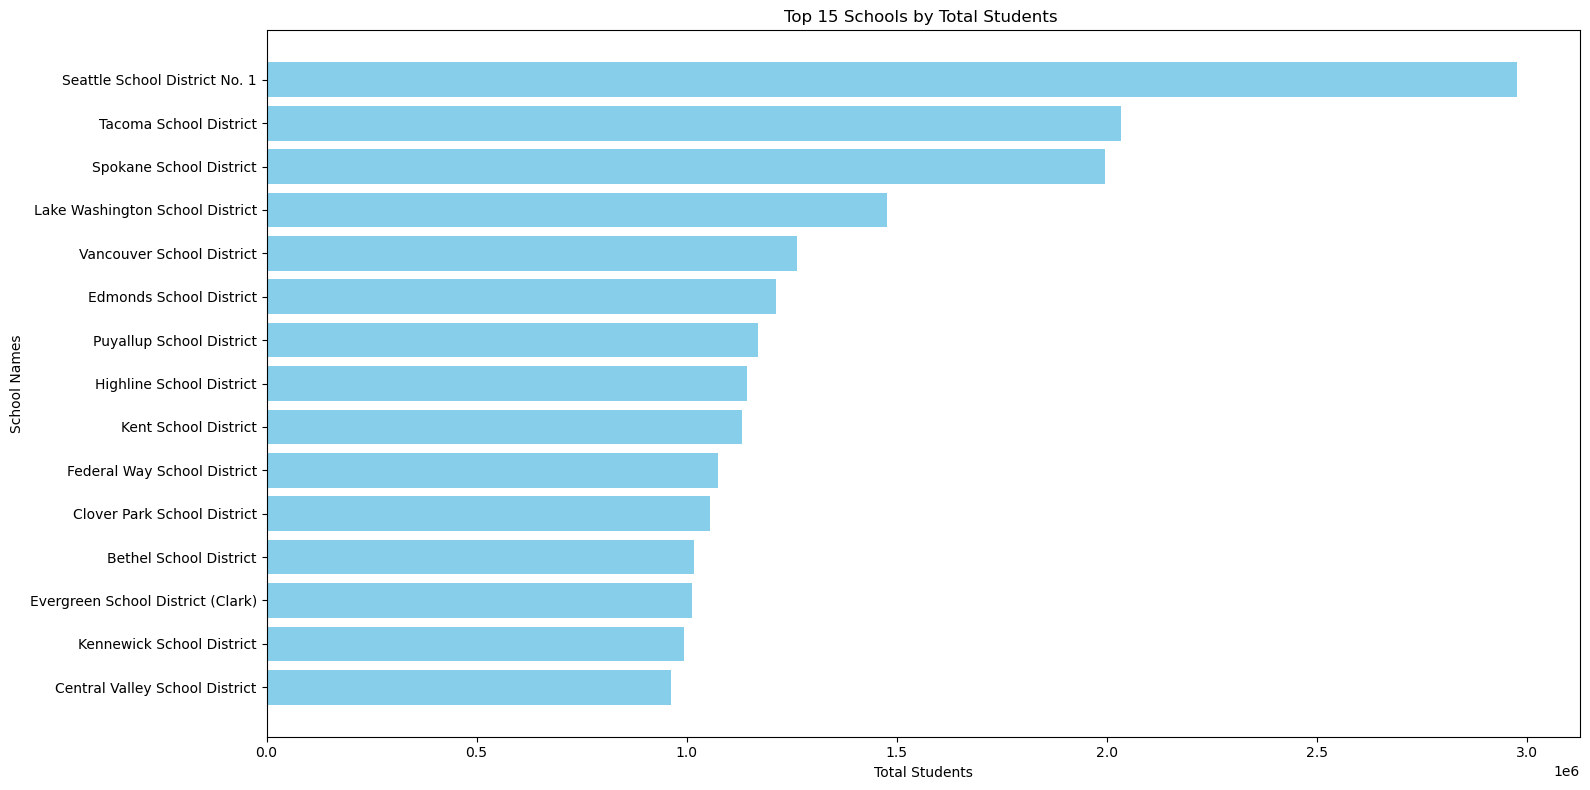

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# Group by SchoolName under DistrictName and sum the 'TotalStudent'
top_schools = df.groupby(['DistrictName',])['TotalStudents'].sum().reset_index()

# We Exclude "State Total" from the dataset
top_schools = top_schools[top_schools['DistrictName'] != 'State Total']

# Sort by 'TotalStudents' in descending order and select the top 20 in the dataset
top_20_schools = top_schools.sort_values(by='TotalStudents', ascending=False).head(15)

# Plotting the top 20 schools in the district
plt.figure(figsize=(16, 8))
plt.barh(top_20_schools['DistrictName'], top_20_schools['TotalStudents'], color='skyblue')
plt.xlabel('Total Students')
plt.ylabel('School Names')
plt.title('Top 15 Schools by Total Students ')
plt.gca().invert_yaxis() 
plt.tight_layout()

# Show the graph
plt.show()

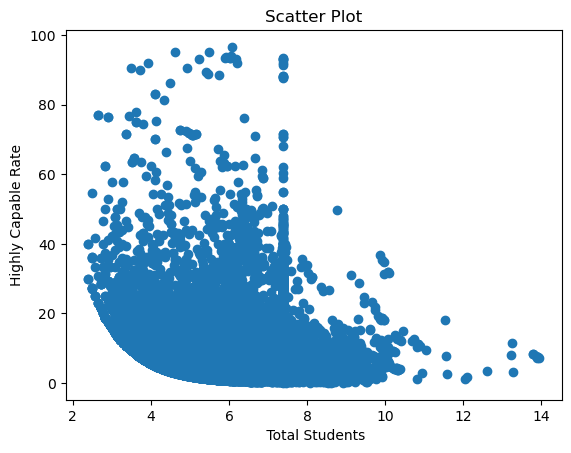

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# Filtering out rows where 'TotalStudents' contains "State Total"
df_filtered = df[df['TotalStudents'] != 'State Total']

# We Convert 'TotalStudents' to numeric (in case there is  a string)
df_filtered['TotalStudents'] = pd.to_numeric(df_filtered['TotalStudents'], errors='coerce')

# Apply log transformation
df_filtered['LogTotalStudents'] = np.log1p(df_filtered['TotalStudents'])

# Plot the scatter plot
plt.scatter(df_filtered['LogTotalStudents'], df_filtered['HighlyCapableRate'])
plt.xlabel(' Total Students')
plt.ylabel('Highly Capable Rate')
plt.title('Scatter Plot')
plt.show()

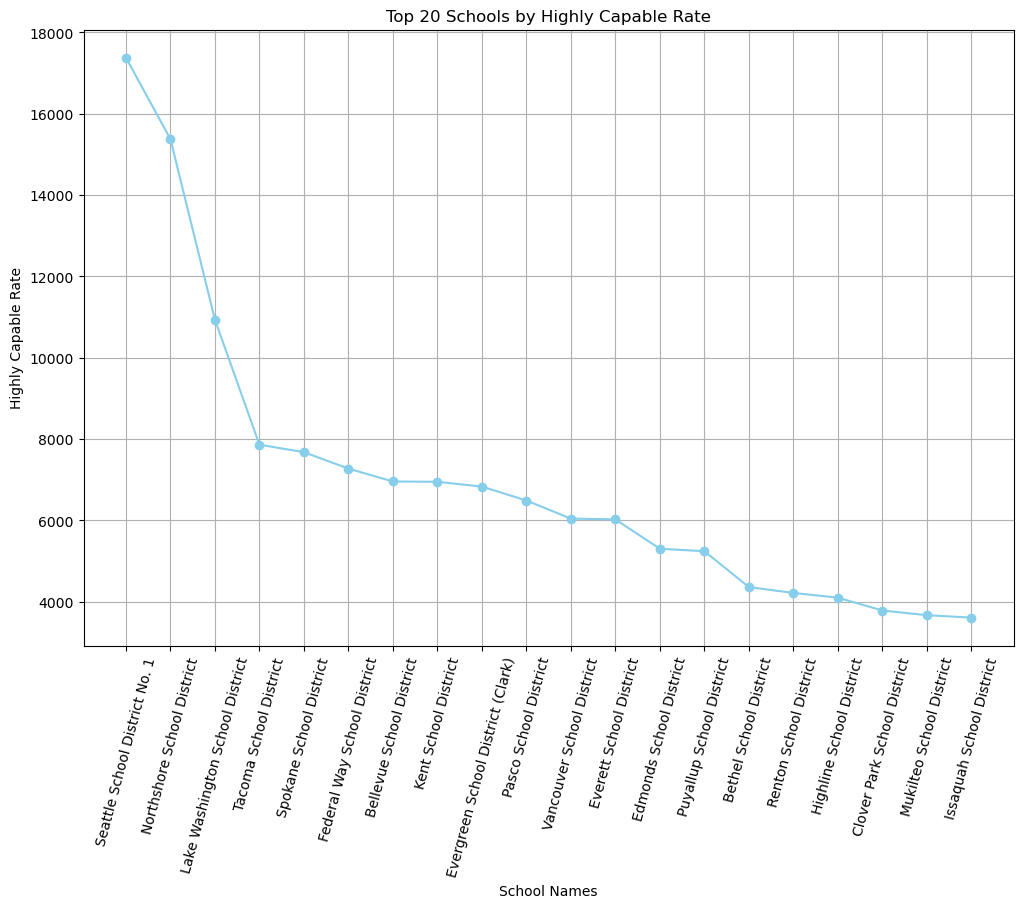

In [57]:
# Group by 'DistrictName' and sum the 'HighlyCapableRate'
top_schools = df.groupby(['DistrictName'])['HighlyCapableRate'].sum().reset_index()

# We exclude "State Total" from the dataset
top_schools = top_schools[top_schools['DistrictName'] != 'State Total']

# Sort by 'HighlyCapableRate' in descending order and select the top 20 districts
top_20_schools = top_schools.sort_values(by='HighlyCapableRate', ascending=False).head(20)

# Plotting the top 20 schools using a line chart
plt.figure(figsize=(12, 8))
plt.plot(top_20_schools['DistrictName'], top_20_schools['HighlyCapableRate'], marker='o', linestyle='-', color='skyblue')

# Formatting the chart
plt.xlabel('School Names')
plt.ylabel('Highly Capable Rate')
plt.title('Top 20 Schools by Highly Capable Rate')
plt.xticks(rotation=75)  # Rotate x-axis labels for better visibility
plt.grid(True)

# Show the graph
plt.show()

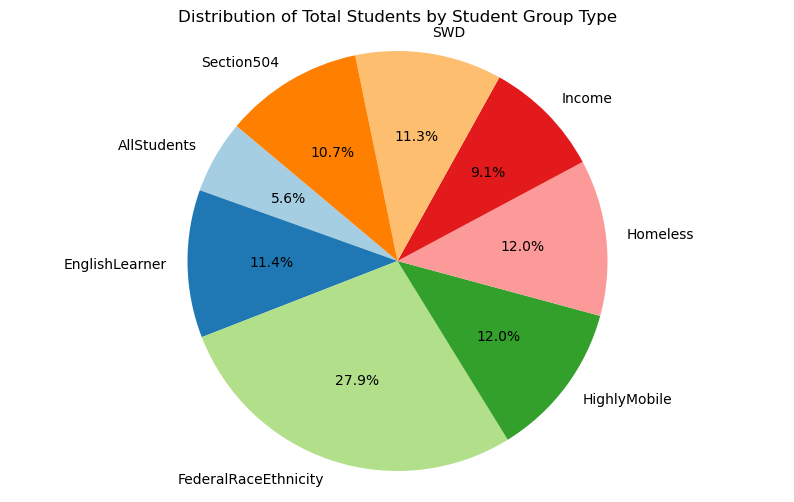

In [59]:
# We group by 'StudentGroupType' and sum the 'TotalStudents'
student_group_data = df.groupby('StudentGroupType')['TotalStudents'].sum().reset_index()

# Plot the pie chart
plt.figure(figsize=(10, 6))
plt.pie(student_group_data['TotalStudents'], labels=student_group_data['StudentGroupType'], 
        autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)

# displaying title
plt.title('Distribution of Total Students by Student Group Type')
plt.axis('equal')  
plt.show()

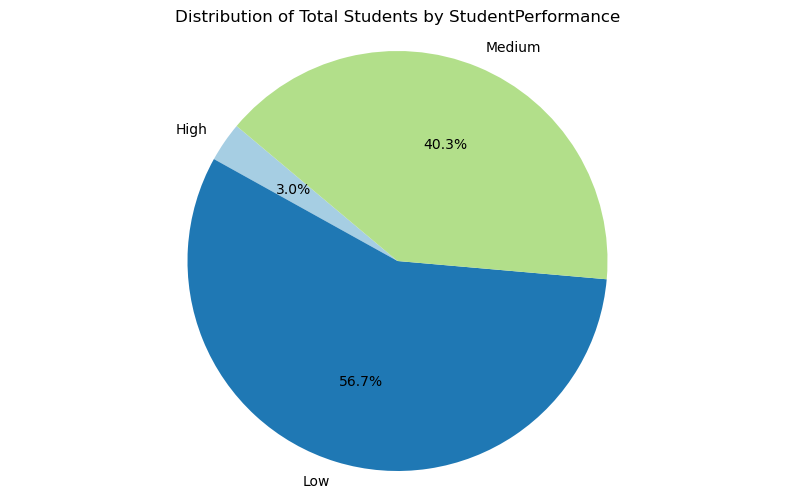

In [61]:
# We group by 'StudentGroupType' and sum the 'TotalStudents'
student_group_data = df.groupby('StudentPerformance')['TotalStudents'].sum().reset_index()

# Plot the pie chart
plt.figure(figsize=(10, 6))
plt.pie(student_group_data['TotalStudents'], labels=student_group_data['StudentPerformance'], 
        autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)

# displaying title
plt.title('Distribution of Total Students by StudentPerformance')
plt.axis('equal')  
plt.show()

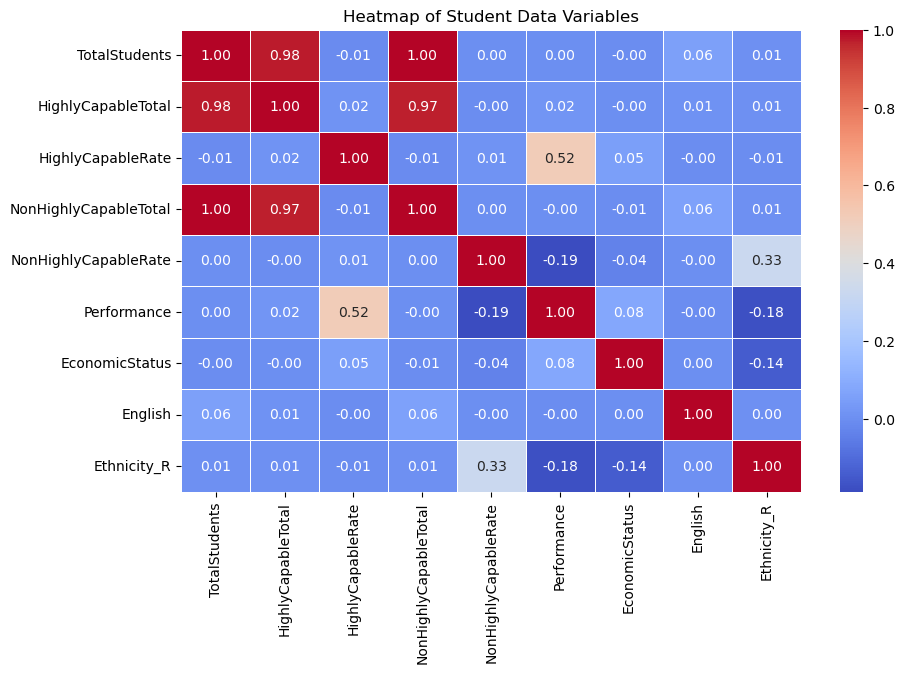

In [63]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# We select only numerical columns for correlation analysis
numeric_cols = ['TotalStudents', 'HighlyCapableTotal', 'HighlyCapableRate', 
                'NonHighlyCapableTotal', 'NonHighlyCapableRate', 
                'Performance', 'EconomicStatus','English','Ethnicity_R']

df_numeric = df[numeric_cols]  # Filter numerical columns

# Compute correlation matrix
corr_matrix = df_numeric.corr()

# Create heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Student Data Variables")
plt.show()

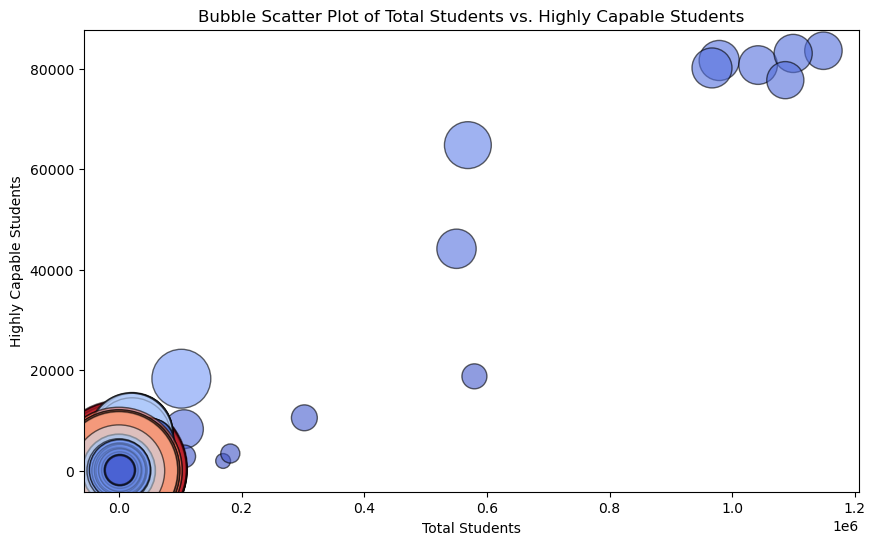

In [65]:
import matplotlib.pyplot as plt


if "TotalStudents" in df.columns and "HighlyCapableTotal" in df.columns and "HighlyCapableRate" in df.columns:
    
    # Extract relevant data
    x = df["TotalStudents"]  s
    y = df["HighlyCapableTotal"]  
    size = df["HighlyCapableRate"] * 100  # Bubble size (scaled for visibility)

    # Create the bubble scatter plot
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, s=size, alpha=0.6, c=size, cmap="coolwarm", edgecolors="black")

    # Labels and title
    plt.xlabel("Total Students")
    plt.ylabel("Highly Capable Students")
    plt.title("Bubble Scatter Plot of Total Students vs. Highly Capable Students")

    # Show plot
    plt.show()
else:
    print("Error: One or more required columns are missing in the DataFrame.")

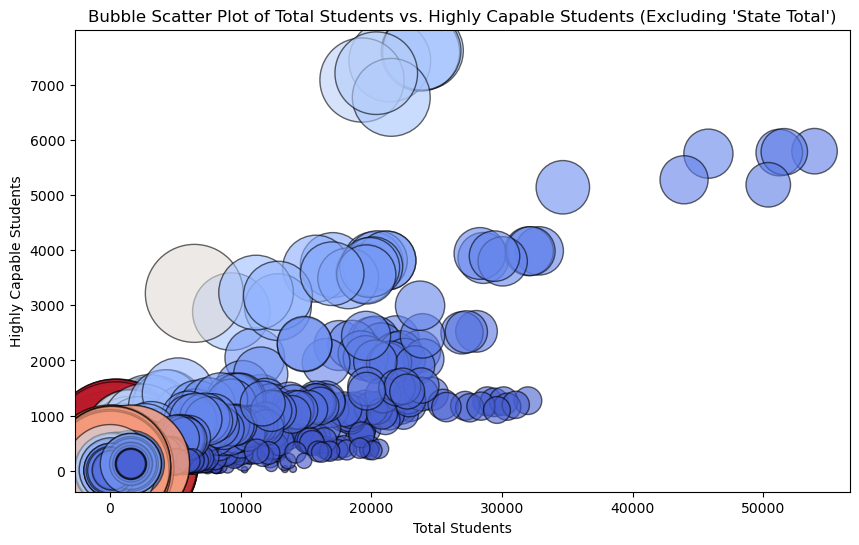

In [67]:
import matplotlib.pyplot as plt

# Ensure df has the required columns
if all(col in df.columns for col in ["TotalStudents", "HighlyCapableTotal", "HighlyCapableRate", "DistrictName"]):

    # Exclude 'State Total' rows
    df_filtered = df[df["DistrictName"] != "State Total"]

    # Extract relevant data
    x = df_filtered["TotalStudents"]  
    y = df_filtered["HighlyCapableTotal"]  
    size = df_filtered["HighlyCapableRate"] * 100  # Bubble size (scaled for visibility)

    # Create the bubble scatter plot
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, s=size, alpha=0.6, c=size, cmap="coolwarm", edgecolors="black")

    # Labels and title
    plt.xlabel("Total Students")
    plt.ylabel("Highly Capable Students")
    plt.title("Bubble Scatter Plot of Total Students vs. Highly Capable Students (Excluding 'State Total')")

    # Show plot
    plt.show()

else:
    print("Error: One or more required columns are missing in the DataFrame.")


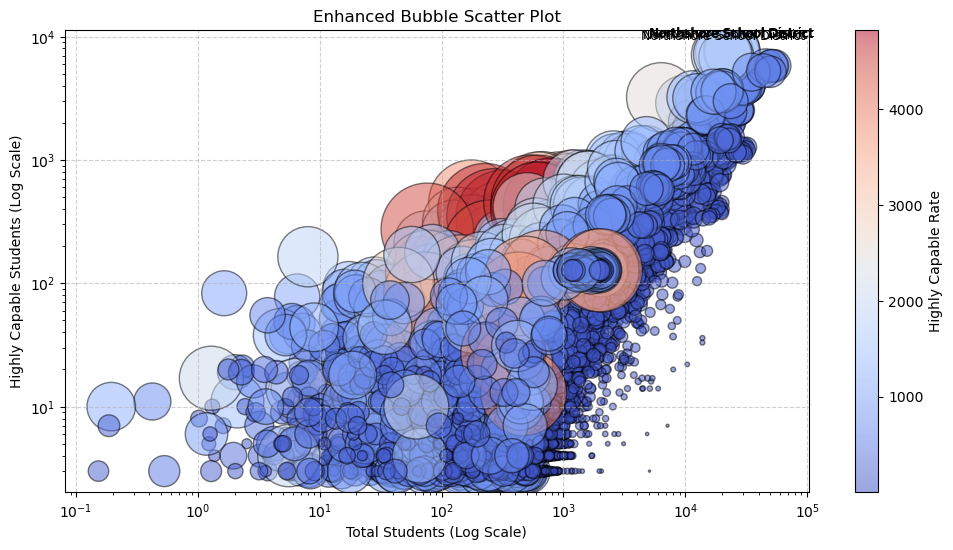

In [69]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Ensure required columns exist
if all(col in df.columns for col in ["TotalStudents", "HighlyCapableTotal", "HighlyCapableRate", "DistrictName"]):

    # We exclude 'State Total' rows
    df_filtered = df[df["DistrictName"] != "State Total"]

    # Apply jittering to TotalStudents to reduce overlap
    x_jittered = df_filtered["TotalStudents"] + np.random.uniform(-500, 500, size=len(df_filtered))
    y = df_filtered["HighlyCapableTotal"]
    size = df_filtered["HighlyCapableRate"] * 50  

    # Apply log scale to spread data evenly
    plt.figure(figsize=(12, 6))
    plt.xscale("log")
    plt.yscale("log")

    # We create scatter plot with adjusted transparency and color coding
    scatter = plt.scatter(x_jittered, y, s=size, alpha=0.5, c=size, cmap="coolwarm", edgecolors="black")

    # Labels and title
    plt.xlabel("Total Students (Log Scale)")
    plt.ylabel("Highly Capable Students (Log Scale)")
    plt.title("Enhanced Bubble Scatter Plot")

    # Add color bar
    plt.colorbar(scatter, label="Highly Capable Rate")
 # Add gridlines for readability
    plt.grid(True, linestyle="--", alpha=0.6)

    #  top 5 schools with highest Highly Capable Total
    top_bubbles = df_filtered.nlargest(5, "HighlyCapableTotal")
    for idx, row in top_bubbles.iterrows():
        plt.annotate(f"{row['DistrictName']}", 
                     (row["TotalStudents"], row["HighlyCapableTotal"]),
                     textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9, color='black')

    # Show plot
    plt.show()


In [71]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, f_classif
from sklearn.metrics import accuracy_score, classification_report
from scipy.stats import pearsonr


In [77]:
print(df)

       OrgLevel                   DistrictName      StudentGroupType  \
0         State                    State Total           AllStudents   
1         State                    State Total        EnglishLearner   
2         State                    State Total        EnglishLearner   
3         State                    State Total  FederalRaceEthnicity   
4         State                    State Total  FederalRaceEthnicity   
...         ...                            ...                   ...   
51819  District  Paschal Sherman Indian School              Homeless   
51820  District  Paschal Sherman Indian School                Income   
51821  District  Paschal Sherman Indian School                Income   
51822  District  Paschal Sherman Indian School            Section504   
51823  District  Paschal Sherman Indian School                   SWD   

                          StudentGroup  TotalStudents  HighlyCapableTotal  \
0                         All Students   1.148732e+06     

In [79]:
df.to_csv("project15.csv", index=False)

## Additional Visuals

333


<Figure size 1200x600 with 0 Axes>

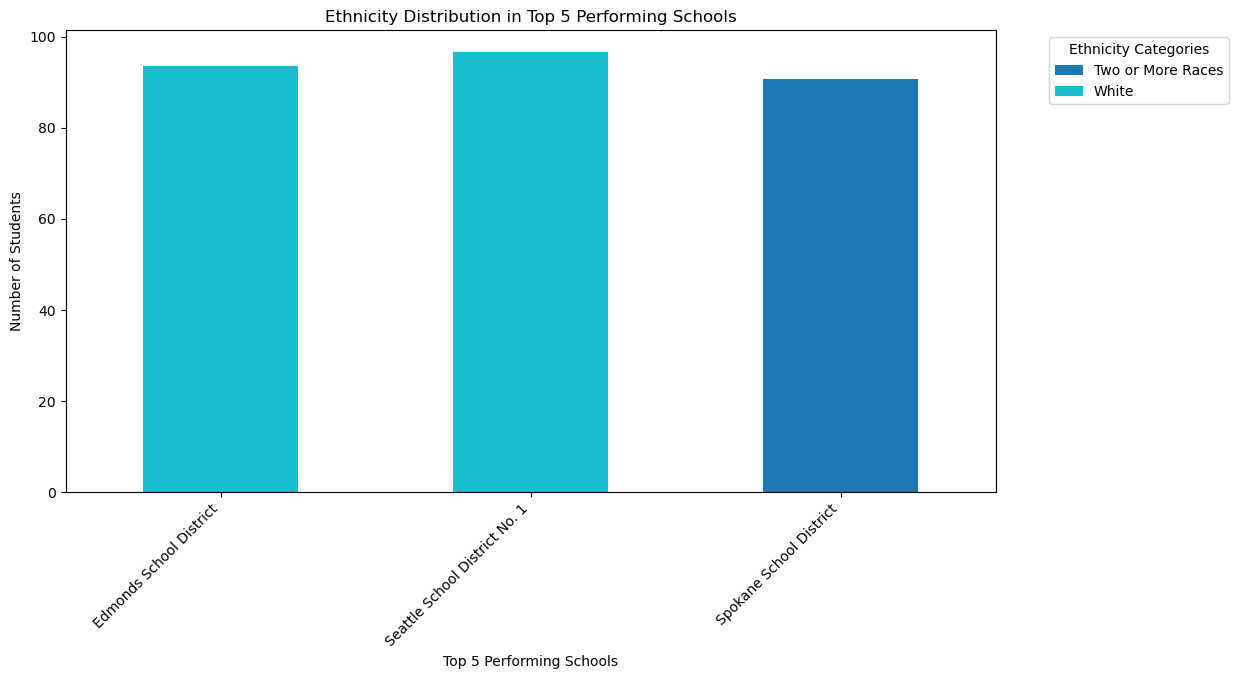

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Check unique school names available
print(df["DistrictName"].nunique())  # Check how many unique schools exist
# We exclude "State Total" from the dataset
top_schools = top_schools[top_schools['DistrictName'] != 'State Total']


# Filter the top 5 performing schools (assuming higher 'Performance' is better)
top_schools = df.sort_values(by="HighlyCapableRate", ascending=False).groupby("DistrictName").head(1).head(3)

# Ensure 'Ethnicity' column exists
if 'Ethnicity' not in df.columns:
    raise ValueError("The dataset does not contain 'Ethnicity' column.")

# Pivot table for stacking ethnicities in schools
ethnicity_distribution = top_schools.pivot_table(index="DistrictName", columns="Ethnicity", values="HighlyCapableRate", aggfunc="sum")

# Plot stacked bar chart for top 5 schools
plt.figure(figsize=(12,6))
ethnicity_distribution.plot(kind="bar", stacked=True, figsize=(12,6), colormap="tab10")

# Formatting the plot
plt.xticks(rotation=45, ha="right")
plt.xlabel("Top 5 Performing Schools")
plt.ylabel("Number of Students")
plt.title("Ethnicity Distribution in Top 5 Performing Schools")
plt.legend(title="Ethnicity Categories", bbox_to_anchor=(1.05, 1), loc="upper left")

# Show the plot
plt.show()


<Figure size 1200x600 with 0 Axes>

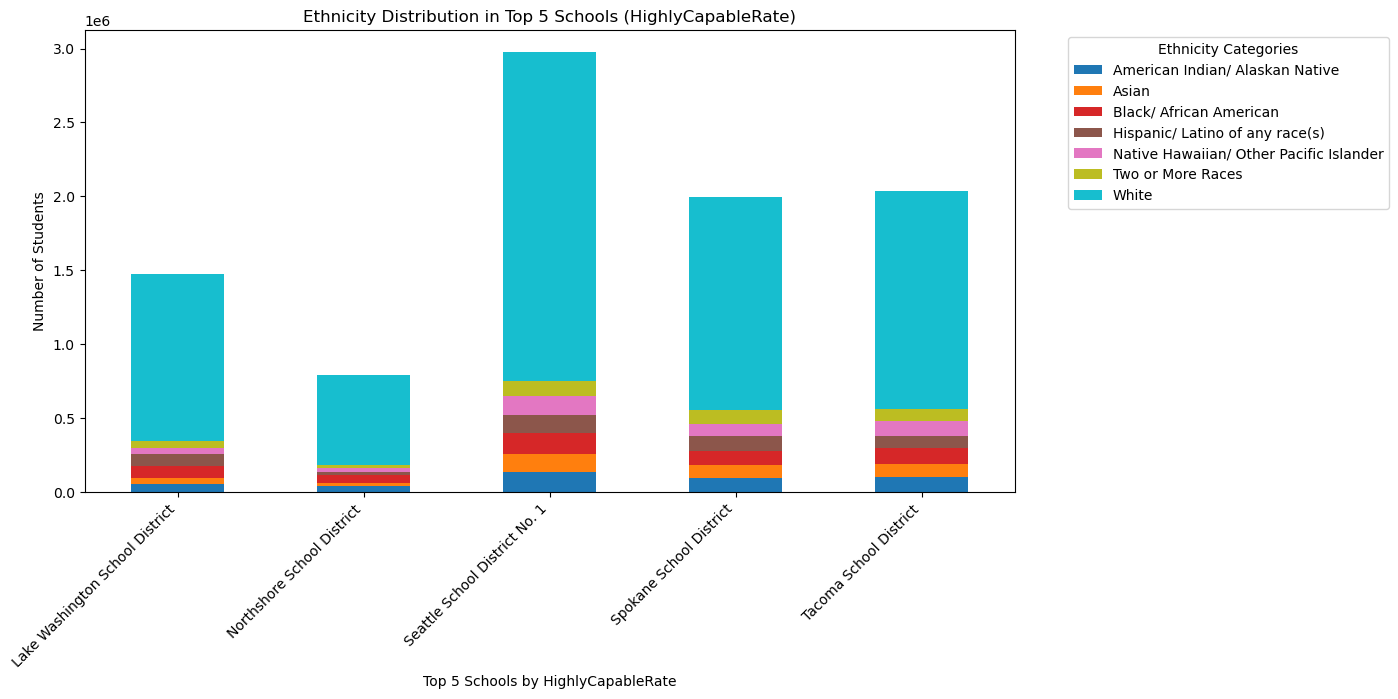

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Group by 'DistrictName' and sum the 'HighlyCapableRate'
top_schools = df.groupby(["DistrictName"])["HighlyCapableRate"].sum().reset_index()

# Exclude "State Total" if present
top_schools = top_schools[top_schools["DistrictName"] != "State Total"]

# Sort by 'HighlyCapableRate' in descending order and select the top 5 districts
top_5_schools = top_schools.sort_values(by="HighlyCapableRate", ascending=False).head(5)

# Filter the original dataset to keep only the top 5 schools for ethnicity analysis
top_5_ethnicity = df[df["DistrictName"].isin(top_5_schools["DistrictName"])]

# Pivot table for stacking ethnicities in schools
ethnicity_distribution = top_5_ethnicity.pivot_table(index="DistrictName", columns="Ethnicity", values="TotalStudents", aggfunc="sum")

# Plot stacked bar chart
plt.figure(figsize=(12,6))
ethnicity_distribution.plot(kind="bar", stacked=True, figsize=(12,6), colormap="tab10")

# Formatting
plt.xticks(rotation=45, ha="right")
plt.xlabel("Top 5 Schools by HighlyCapableRate")
plt.ylabel("Number of Students")
plt.title("Ethnicity Distribution in Top 5 Schools (HighlyCapableRate)")
plt.legend(title="Ethnicity Categories", bbox_to_anchor=(1.05, 1), loc="upper left")

# Show the plot
plt.show()


C:\Users\eclin\AppData\Local\Temp\ipykernel_7544\1754399293.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_5_data["Ethnicity"] = top_5_data["Ethnicity"].fillna("white")



Final Dominant Ethnicities per School:
                           DistrictName          Ethnicity  HighlyCapableRate
13707  Lake Washington School District              Asian              59.56
15422       Northshore School District              Asian              75.41
39358    Seattle School District No. 1              White              96.56
28120          Spokane School District  Two or More Races              90.63
20210           Tacoma School District              Asian              25.00


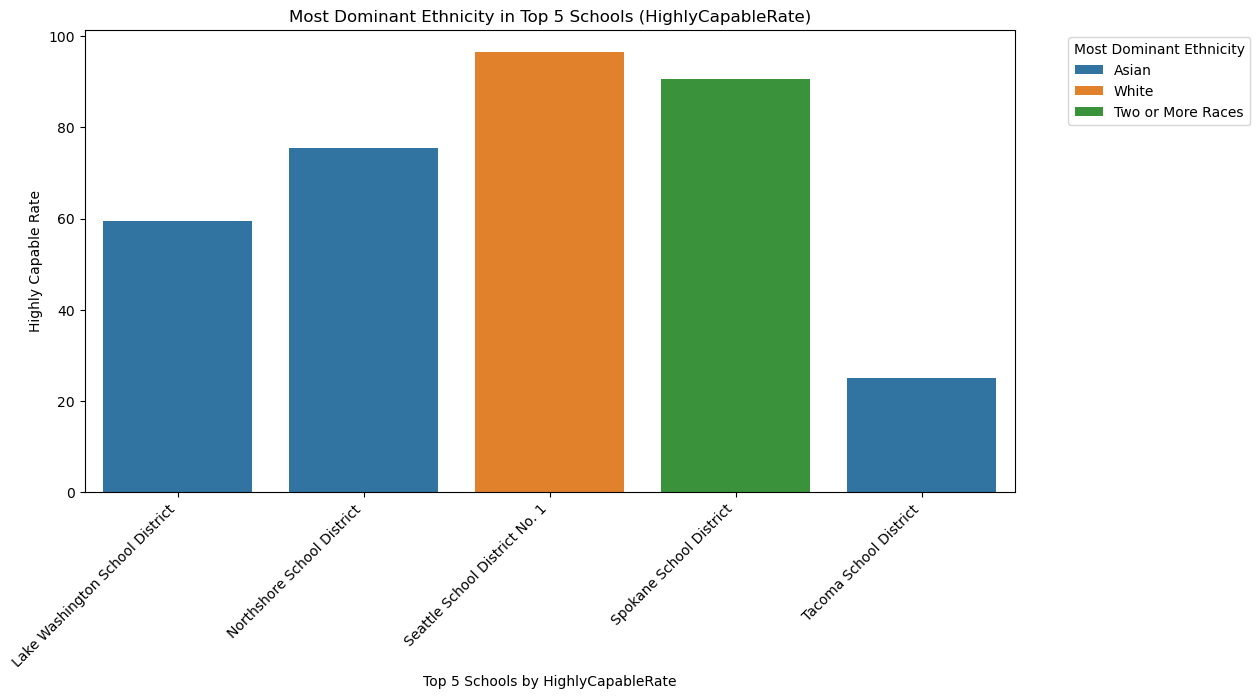

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Remove "State Total" if present
df = df[df['DistrictName'] != 'State Total']

# Get the top 5 schools by HighlyCapableRate
top_schools = df.groupby("DistrictName")["HighlyCapableRate"].sum().reset_index()
top_schools = top_schools.sort_values(by="HighlyCapableRate", ascending=False).head(5)

# Filter dataset to include only the top 5 schools
top_5_data = df[df["DistrictName"].isin(top_schools["DistrictName"])]

# **Fix: Ensure no missing Ethnicity values**
top_5_data["Ethnicity"] = top_5_data["Ethnicity"].fillna("white")

# **Fix: Select the most dominant ethnicity per school correctly**
dominant_ethnicities = top_5_data.loc[top_5_data.groupby("DistrictName")["HighlyCapableRate"].idxmax()]

# **Fix: Ensure all 5 schools are included**
missing_schools = set(top_schools["DistrictName"]) - set(dominant_ethnicities["DistrictName"])
for school in missing_schools:
    print(f"Warning: No dominant ethnicity found for {school}, assigning 'Unknown'")
    dominant_ethnicities = dominant_ethnicities.append(
        {"DistrictName": school, "Ethnicity": "Unknown", "HighlyCapableRate": 0}, ignore_index=True
    )

# Debug print to check the final dataset
print("\nFinal Dominant Ethnicities per School:\n", dominant_ethnicities[["DistrictName", "Ethnicity", "HighlyCapableRate"]])

# Plot the most dominant ethnicity for each of the top 5 schools
plt.figure(figsize=(12,6))
sns.barplot(data=dominant_ethnicities, x="DistrictName", y="HighlyCapableRate", hue="Ethnicity", dodge=False, palette="tab10")

# Formatting the plot
plt.xticks(rotation=45, ha="right")
plt.xlabel("Top 5 Schools by HighlyCapableRate")
plt.ylabel("Highly Capable Rate")
plt.title("Most Dominant Ethnicity in Top 5 Schools (HighlyCapableRate)")
plt.legend(title="Most Dominant Ethnicity", bbox_to_anchor=(1.05, 1), loc="upper left")

# Show the plot
plt.show()


C:\Users\eclin\AppData\Local\Temp\ipykernel_7544\4126493419.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_5_data["SocioEconomicStatus"] = top_5_data["SocioEconomicStatus"].fillna("Unknown")


<Figure size 1200x600 with 0 Axes>

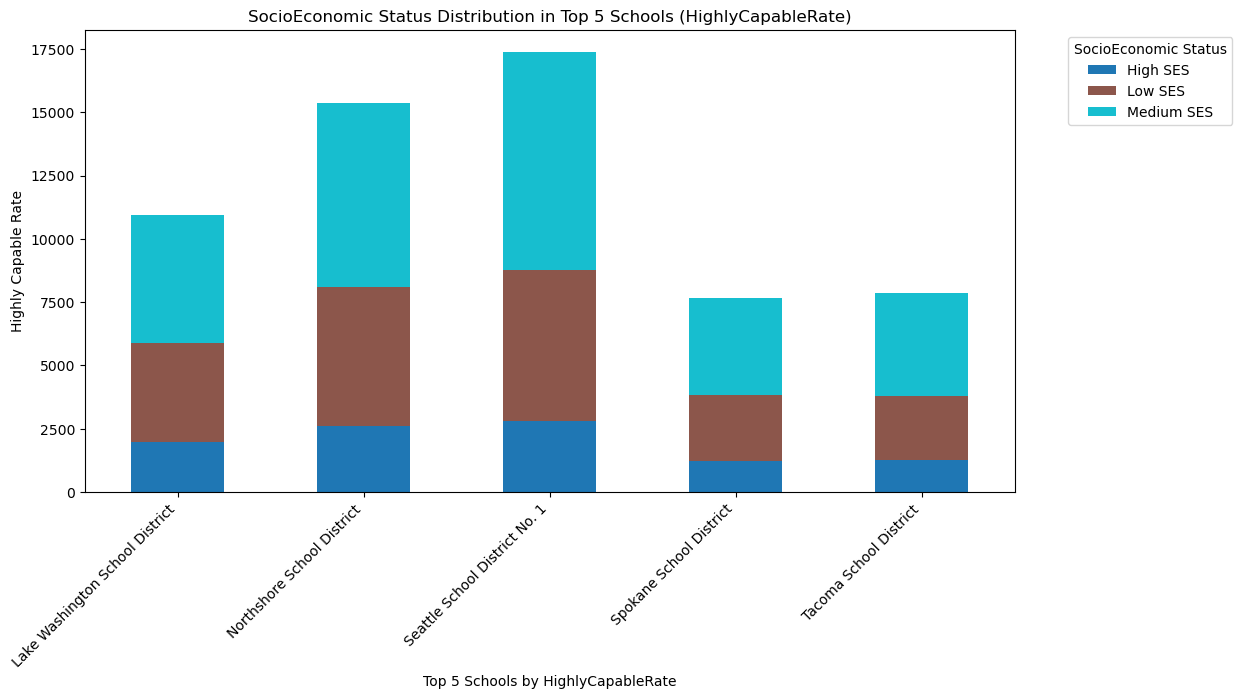

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Remove "State Total" if present
df = df[df['DistrictName'] != 'State Total']

# Get the top 5 schools by HighlyCapableRate
top_schools = df.groupby("DistrictName")["HighlyCapableRate"].sum().reset_index()
top_schools = top_schools.sort_values(by="HighlyCapableRate", ascending=False).head(5)

# Filter dataset to include only the top 5 schools
top_5_data = df[df["DistrictName"].isin(top_schools["DistrictName"])]

# **Fix: Ensure no missing SocioEconomicStatus values**
top_5_data["SocioEconomicStatus"] = top_5_data["SocioEconomicStatus"].fillna("Unknown")

# **Pivot Table to Summarize SocioEconomicStatus**
ses_distribution = top_5_data.pivot_table(index="DistrictName", columns="SocioEconomicStatus", values="HighlyCapableRate", aggfunc="sum")

# **Plot the Stacked Bar Chart**
plt.figure(figsize=(12,6))
ses_distribution.plot(kind="bar", stacked=True, figsize=(12,6), colormap="tab10")

# Formatting the plot
plt.xticks(rotation=45, ha="right")
plt.xlabel("Top 5 Schools by HighlyCapableRate")
plt.ylabel("Highly Capable Rate")
plt.title("SocioEconomic Status Distribution in Top 5 Schools (HighlyCapableRate)")
plt.legend(title="SocioEconomic Status", bbox_to_anchor=(1.05, 1), loc="upper left")

# Show the plot
plt.show()


C:\Users\eclin\AppData\Local\Temp\ipykernel_7544\3253188223.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_5_data["StudentGroupType"] = top_5_data["StudentGroupType"].fillna("Unknown")


<Figure size 1200x600 with 0 Axes>

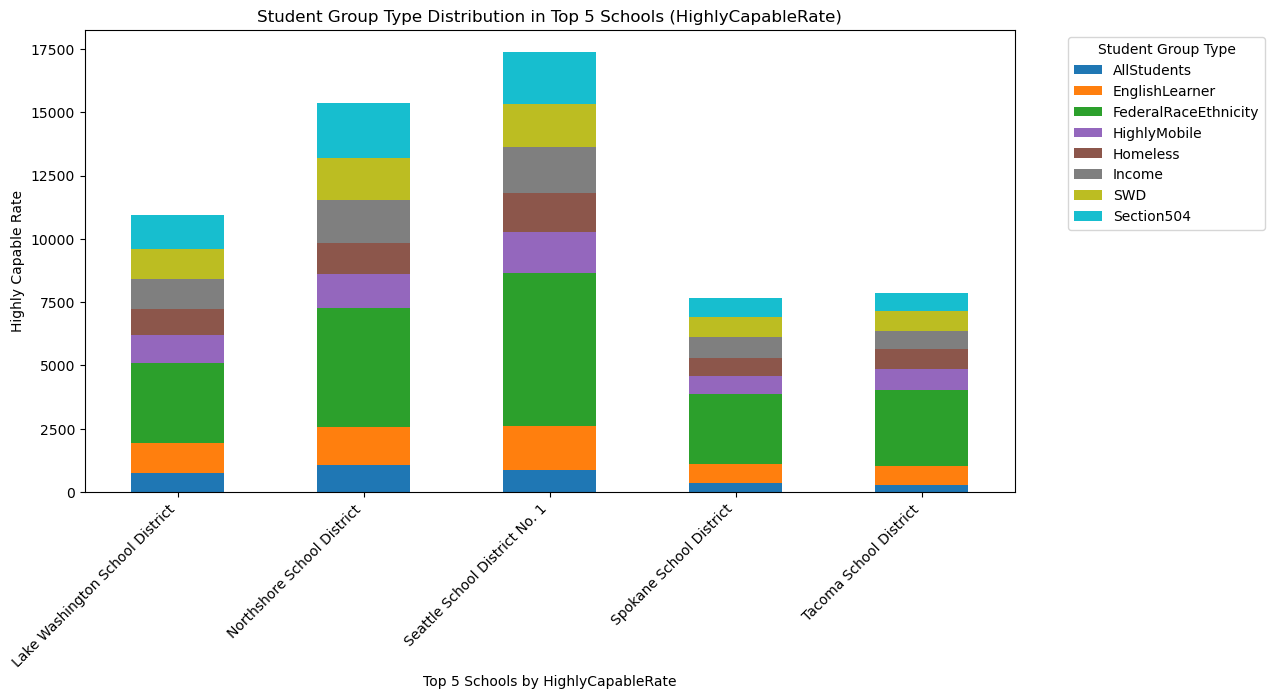

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Remove "State Total" if present
df = df[df['DistrictName'] != 'State Total']

# Get the top 5 schools by HighlyCapableRate
top_schools = df.groupby("DistrictName")["HighlyCapableRate"].sum().reset_index()
top_schools = top_schools.sort_values(by="HighlyCapableRate", ascending=False).head(5)

# Filter dataset to include only the top 5 schools
top_5_data = df[df["DistrictName"].isin(top_schools["DistrictName"])]

# **Fix: Ensure no missing StudentGroupType values**
top_5_data["StudentGroupType"] = top_5_data["StudentGroupType"].fillna("Unknown")

# **Pivot Table to Summarize StudentGroupType**
student_group_distribution = top_5_data.pivot_table(index="DistrictName", columns="StudentGroupType", values="HighlyCapableRate", aggfunc="sum")

# **Plot the Stacked Bar Chart**
plt.figure(figsize=(12,6))
student_group_distribution.plot(kind="bar", stacked=True, figsize=(12,6), colormap="tab10")

# Formatting the plot
plt.xticks(rotation=45, ha="right")
plt.xlabel("Top 5 Schools by HighlyCapableRate")
plt.ylabel("Highly Capable Rate")
plt.title("Student Group Type Distribution in Top 5 Schools (HighlyCapableRate)")
plt.legend(title="Student Group Type", bbox_to_anchor=(1.05, 1), loc="upper left")

# Show the plot
plt.show()


C:\Users\eclin\AppData\Local\Temp\ipykernel_7544\3816476460.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_5_data["StudentGroupType"] = top_5_data["StudentGroupType"].fillna("Unknown")


<Figure size 1200x600 with 0 Axes>

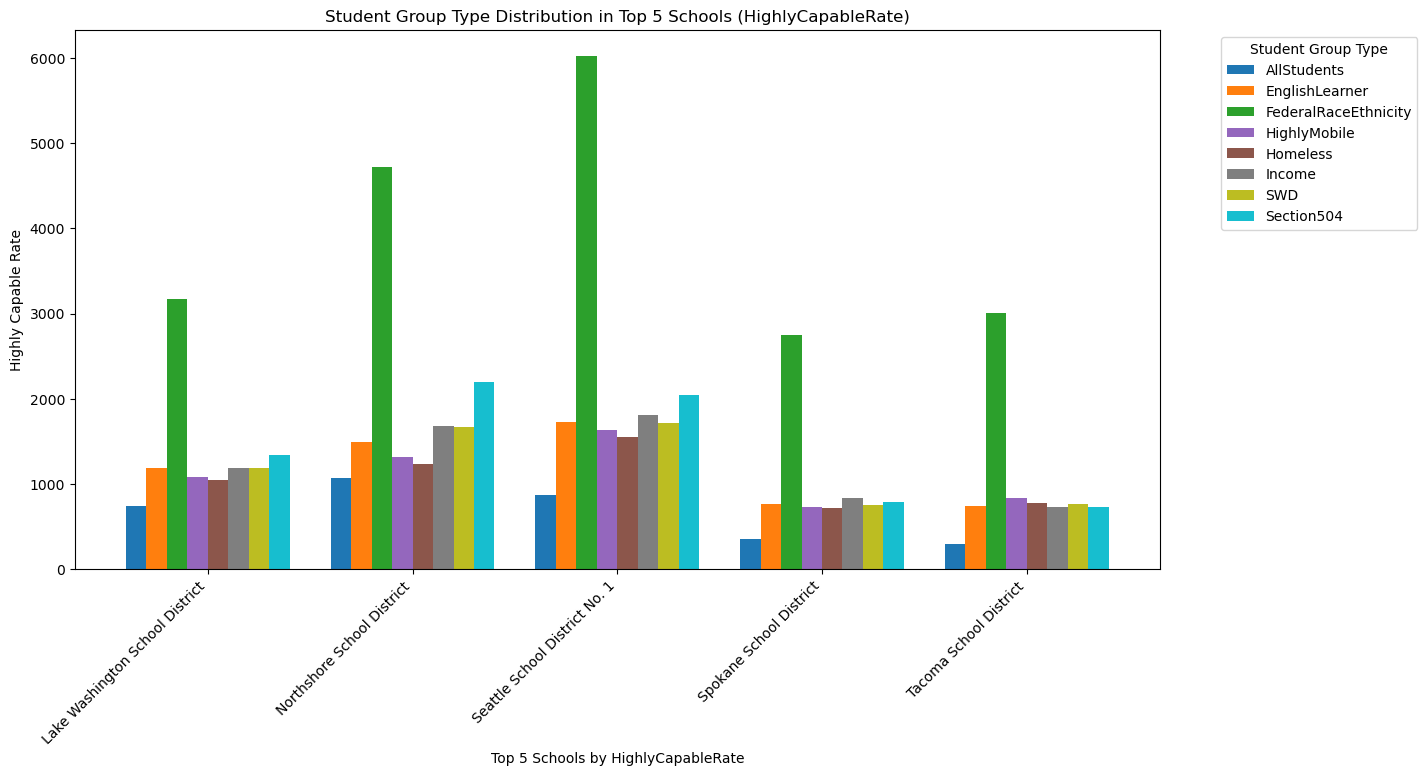

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Remove "State Total" if present
df = df[df['DistrictName'] != 'State Total']

# Get the top 5 schools by HighlyCapableRate
top_schools = df.groupby("DistrictName")["HighlyCapableRate"].sum().reset_index()
top_schools = top_schools.sort_values(by="HighlyCapableRate", ascending=False).head(5)

# Filter dataset to include only the top 5 schools
top_5_data = df[df["DistrictName"].isin(top_schools["DistrictName"])]

# Ensure no missing StudentGroupType values
top_5_data["StudentGroupType"] = top_5_data["StudentGroupType"].fillna("Unknown")

# Pivot Table for Grouped Bar Chart
student_group_distribution = top_5_data.pivot_table(index="DistrictName", columns="StudentGroupType", values="HighlyCapableRate", aggfunc="sum")

# Plot the grouped bar chart
plt.figure(figsize=(12,6))
student_group_distribution.plot(kind="bar", figsize=(14,7), colormap="tab10", width=0.8)

# Formatting the plot
plt.xticks(rotation=45, ha="right")
plt.xlabel("Top 5 Schools by HighlyCapableRate")
plt.ylabel("Highly Capable Rate")
plt.title("Student Group Type Distribution in Top 5 Schools (HighlyCapableRate)")
plt.legend(title="Student Group Type", bbox_to_anchor=(1.05, 1), loc="upper left")

# Show the plot
plt.show()


In [96]:
# Convert HighlyCapableRate to binary
df["HighlyCapableRate"] = df["HighlyCapableRate"].apply(lambda x: 1 if x >= 8 else 0)

# Display first few rows to verify the changes
print(df.head())


   OrgLevel               DistrictName      StudentGroupType  \
20   School  Washtucna School District           AllStudents   
21   School  Washtucna School District        EnglishLearner   
22   School  Washtucna School District  FederalRaceEthnicity   
23   School  Washtucna School District  FederalRaceEthnicity   
24   School  Washtucna School District  FederalRaceEthnicity   

                       StudentGroup  TotalStudents  HighlyCapableTotal  \
20                     All Students      83.000000           11.000000   
21    Non-English Language Learners      83.000000           11.000000   
22  American Indian/ Alaskan Native    1609.121575          127.228268   
23  Hispanic/ Latino of any race(s)    1609.121575          127.228268   
24                Two or More Races    1609.121575          127.228268   

    HighlyCapableRate  NonHighlyCapableTotal  NonHighlyCapableRate  English  \
20                  1              72.000000                 86.75    808.0   
21          

In [98]:
# List of columns to drop
drop_cols = ["OrgLevel", "StudentGroupType", "StudentGroup", "StudentPerformance", "SocioEconomicStatus"]

# Drop the columns
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

# Display the first few rows to verify changes
print(df.head())


                 DistrictName  TotalStudents  HighlyCapableTotal  \
20  Washtucna School District      83.000000           11.000000   
21  Washtucna School District      83.000000           11.000000   
22  Washtucna School District    1609.121575          127.228268   
23  Washtucna School District    1609.121575          127.228268   
24  Washtucna School District    1609.121575          127.228268   

    HighlyCapableRate  NonHighlyCapableTotal  NonHighlyCapableRate  English  \
20                  1              72.000000                 86.75    808.0   
21                  1              72.000000                 86.75    805.0   
22                  0            1481.893307                  5.00    435.0   
23                  0            1481.893307                  5.00    934.0   
24                  0            1481.893307                  5.00    122.0   

                          Ethnicity  Ethnicity_R  Performance  EconomicStatus  
20                            White 

In [100]:
# Drop the 'Ethnicity' column
df = df.drop(columns=['Ethnicity', 'DistrictName'])

# Display the updated DataFrame
print(df.head())

    TotalStudents  HighlyCapableTotal  HighlyCapableRate  \
20      83.000000           11.000000                  1   
21      83.000000           11.000000                  1   
22    1609.121575          127.228268                  0   
23    1609.121575          127.228268                  0   
24    1609.121575          127.228268                  0   

    NonHighlyCapableTotal  NonHighlyCapableRate  English  Ethnicity_R  \
20              72.000000                 86.75    808.0            9   
21              72.000000                 86.75    805.0            9   
22            1481.893307                  5.00    435.0            4   
23            1481.893307                  5.00    934.0            8   
24            1481.893307                  5.00    122.0            9   

    Performance  EconomicStatus  
20            2               2  
21            2               3  
22            2               2  
23            2               2  
24            2               

## Model Development

In [103]:
df = df.drop('NonHighlyCapableRate', axis=1)

In [105]:
# Define features and target
X = df.drop(columns=["HighlyCapableRate"])  # Features
y = df["HighlyCapableRate"]  # Target variable

In [107]:
# Why is it a Filter Method?
#Filter methods rank features using statistical techniques before model training.
#They are fast, scalable, and work well with high-dimensional datasets.
#The ANOVA F-test (f_classif) measures how well each feature differentiates the target variable (y).

In [109]:
# 1. Feature Selection using SelectKBest
selector = SelectKBest(score_func=f_classif, k=8)  # Select top  features
X_new = selector.fit_transform(X, y)

C:\Users\eclin\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:776: UserWarning: k=8 is greater than n_features=7. All the features will be returned.
  warnings.warn(


In [111]:
# Get selected feature names
selected_features = X.columns[selector.get_support()]
print("Selected Features by SelectKBest:", selected_features)

Selected Features by SelectKBest: Index(['TotalStudents', 'HighlyCapableTotal', 'NonHighlyCapableTotal',
       'English', 'Ethnicity_R', 'Performance', 'EconomicStatus'],
      dtype='object')


In [113]:
# 2. Feature Importance using Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X, y)

RandomForestClassifier(random_state=42)

In [115]:
# Get feature importances
feature_importances = clf.feature_importances_
importance_df = pd.DataFrame({"Feature": X.columns, "Importance": feature_importances})
importance_df = importance_df.sort_values(by="Importance", ascending=False)


In [117]:
# Display feature importances
print("Feature Importances from Random Forest:")
print(importance_df)

Feature Importances from Random Forest:
                 Feature  Importance
3                English    0.492015
5            Performance    0.190875
1     HighlyCapableTotal    0.137145
2  NonHighlyCapableTotal    0.084801
0          TotalStudents    0.072712
4            Ethnicity_R    0.014226
6         EconomicStatus    0.008228


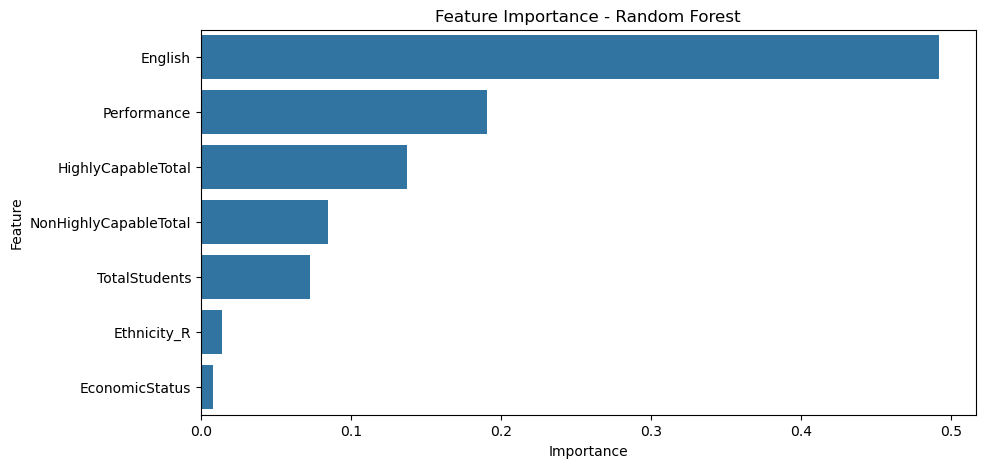

In [158]:
# Plot feature importances
plt.figure(figsize=(10, 5))
sns.barplot(x=importance_df["Importance"], y=importance_df["Feature"])
plt.title("Feature Importance - Random Forest")
plt.show()

## Data Preprocessing

In [121]:
# Define feature set (X) and target variable (y)
X = df.drop(columns=['HighlyCapableRate'])  # Features
y = (df['HighlyCapableRate'] > 0.08).astype(int)  # Binary classification (above 8% rate)



In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [125]:
# Standardize numerical variables
scaler = StandardScaler()
X[['TotalStudents', 'HighlyCapableTotal', 'NonHighlyCapableTotal', 'English','EconomicStatus', 'Ethnicity_R','Performance']] = scaler.fit_transform(X[['TotalStudents', 'HighlyCapableTotal', 'NonHighlyCapableTotal', 'English','EconomicStatus', 'Ethnicity_R','Performance',]])

In [127]:
# Split dataset into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Train Predictive Model (Random Forest)

In [164]:
# Initialize and Train the RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make Predictions
y_pred = model.predict(X_test)

# Model Performance
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy Score: 0.9113985136569829
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94      7817
           1       0.82      0.82      0.82      2544

    accuracy                           0.91     10361
   macro avg       0.88      0.88      0.88     10361
weighted avg       0.91      0.91      0.91     10361



## Model Evaluation

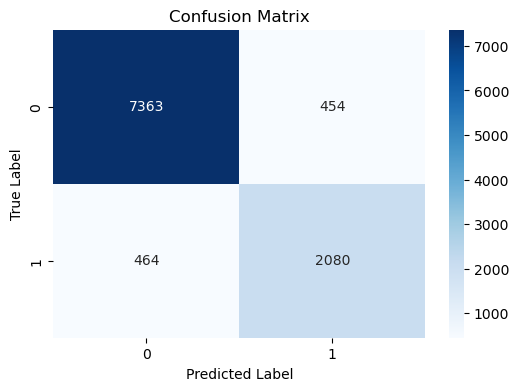

In [133]:
# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Blues", fmt='d')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


## Making Predictions on New Data

In [166]:
# Example: Predict for a new student record
new_data = np.array([[300, 8000, 1, 0.95, 1, 2, 10]])  # Sample input
new_data = scaler.transform(new_data)  # Standardize
prediction = model.predict(new_data)
print("Predicted Class:", "Highly Capable" if prediction[0] == 1 else "Not Highly Capable")
# 300, 12000, 5, 1.0, 3, 50, 1, 10

Predicted Class: Highly Capable


C:\Users\eclin\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\eclin\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [168]:
# New sample input (values intentionally low)
new_data = np.array([[6, 1, 2008, 50, 1, 1, 3, ]])
new_data = scaler.transform(new_data)
prediction = model.predict(new_data)

print("Predicted Class:", "Highly Capable" if prediction[0] == 1 else "Not Highly Capable")


Predicted Class: Not Highly Capable


C:\Users\eclin\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\eclin\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
